In [1]:
import pandas as pd

# Load the FINAL combined dataset
df = pd.read_csv("processed/maternal_modeling_common_features.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["RiskLevel"].value_counts())

print("\nClass distribution (%):")
print((df["RiskLevel"].value_counts(normalize=True) * 100).round(1))

df.head()


Dataset shape: (1880, 10)

Columns:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'PulsePressure', 'MeanArterialPressure', 'RiskLevel', 'data_source']

Missing values: 0
Duplicate rows: 0

Class distribution:
RiskLevel
low risk     780
mid risk     623
high risk    477
Name: count, dtype: int64

Class distribution (%):
RiskLevel
low risk     41.5
mid risk     33.1
high risk    25.4
Name: proportion, dtype: float64


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,MeanArterialPressure,RiskLevel,data_source
0,25,130,80,15.00,98.0,86,50,96.666667,high risk,original
1,35,140,90,13.00,98.0,70,50,106.666667,high risk,original
2,29,90,70,8.00,100.0,80,20,76.666667,high risk,original
3,30,140,85,7.00,98.0,70,55,103.333333,high risk,original
4,23,140,80,7.01,98.0,70,60,100.000000,high risk,original


### 1.4 stratified train/test split


In [2]:
from sklearn.model_selection import train_test_split

# Separate predictors and target.
# IMPORTANT: data_source is metadata only and must NOT be used as a model feature.
X = df.drop(columns=["RiskLevel", "data_source"])
y = df["RiskLevel"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Features used for modeling:")
print(X.columns.tolist())

print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nOverall class distribution:")
print(y.value_counts(normalize=True))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

assert "data_source" not in X.columns
assert "RiskLevel" not in X.columns


Features used for modeling:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'PulsePressure', 'MeanArterialPressure']

Training shape: (1504, 8)
Test shape: (376, 8)

Overall class distribution:
RiskLevel
low risk     0.414894
mid risk     0.331383
high risk    0.253723
Name: proportion, dtype: float64

Training class distribution:
RiskLevel
low risk     0.414894
mid risk     0.331117
high risk    0.253989
Name: proportion, dtype: float64

Test class distribution:
RiskLevel
low risk     0.414894
mid risk     0.332447
high risk    0.252660
Name: proportion, dtype: float64


stratify=y tells Python when you split the dataset, try to keep the same proportion of low-, mid-, and high-risk cases in the training and test sets.

## Model Development

### 2.1 Logistic Regeression

##### 2.1 Logistic Regression Implementation
1. Scale training/test data
2. Apply SMOTE to training data only
3. Create baseline Logistic Regression
4. Hyperparameter tuning
5. Train best Logistic Regression
6. Generate final y_pred_lr

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Build pipeline: scaling -> SMOTE -> Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("lr", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=1000,
        random_state=42
    ))
])

# 2. Hyperparameters to test
param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10, 100]
}

# 3. Hyperparameter tuning using 5-fold cross-validation
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# 4. Train on the training set
grid_search_lr.fit(X_train, y_train)

# 5. Get the best trained model
best_lr_model = grid_search_lr.best_estimator_

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV Macro-F1:", grid_search_lr.best_score_)

# 6. Predict on the untouched test set
y_pred_lr = best_lr_model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

Best parameters: {'lr__C': 0.1}
Best CV Macro-F1: 0.5935293409739868

First 10 predictions:
['mid risk' 'high risk' 'high risk' 'low risk' 'low risk' 'mid risk'
 'mid risk' 'high risk' 'low risk' 'high risk']


### 2.2 Random Forest

##### 2.2 Random Forest Implementation

1. Include SMOTE within the training pipeline
2. Create Random Forest classifier
3. Perform hyperparameter tuning with GridSearchCV
4. Select/use the best Random Forest
5. Generate final `y_pred_rf`


In [4]:
## WITH PIPELINE

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Build pipeline
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

# 2. Hyperparameters to test
param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

# 3. Grid search
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# 4. Fit on ORIGINAL training data
grid_search_rf.fit(X_train, y_train)

# 5. Best pipeline
best_rf_model = grid_search_rf.best_estimator_

print("Best parameters:", grid_search_rf.best_params_)
print("Best CV macro-F1:", grid_search_rf.best_score_)

# 6. Final predictions on untouched test data
y_pred_rf = best_rf_model.predict(X_test)

Best parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best CV macro-F1: 0.6317192041776224


##### SMOTE inside a Pipeline

In this approach, SMOTE and Random Forest are combined inside an `imblearn` Pipeline. During `GridSearchCV`, SMOTE is applied separately within each training fold, while the validation fold remains untouched.

This is more leakage-safe because synthetic samples are generated only from the data available in each training fold. Therefore, this pipeline version is preferred for the final model development and hyperparameter tuning.

### 2.3 Decision Tree


##### 2.3 Decision Tree Implementation

1. Include SMOTE within the training pipeline
2. Create Decision Tree classifier
3. Perform hyperparameter tuning with GridSearchCV
4. Select/use the best Decision Tree
5. Generate final `y_pred_dt`

Decision Tree does not require feature scaling.


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Leakage-safe Decision Tree pipeline
dt_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42))
])

# Hyperparameters to tune
param_grid_dt = {
    "dt__criterion": ["gini", "entropy"],
    "dt__max_depth": [None, 3, 5, 7, 10],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)

best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_test)

print("Best Decision Tree parameters:", grid_search_dt.best_params_)
print("Best CV Macro-F1:", grid_search_dt.best_score_)
print("\nFirst 10 predictions:")
print(y_pred_dt[:10])


Best Decision Tree parameters: {'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Best CV Macro-F1: 0.579473254412742

First 10 predictions:
['mid risk' 'high risk' 'high risk' 'low risk' 'low risk' 'low risk'
 'low risk' 'low risk' 'high risk' 'high risk']


Decision Tree uses the same leakage-safe imbalance-handling strategy as Random Forest: SMOTE is applied only within the training folds of the pipeline during cross-validation. Hyperparameters controlling tree complexity are tuned to reduce overfitting.


### 2.4 Support Vector Machine (SVM)

SVM uses the same experimental conditions as the other models:
- the same `X_train` / `X_test` split,
- scaling inside the pipeline,
- SMOTE inside each cross-validation training fold,
- 5-fold `GridSearchCV`,
- Macro-F1 as the common tuning metric.


In [6]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("svm", SVC(probability=True, random_state=42))
])

param_grid_svm = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["rbf", "linear"],
    "svm__gamma": ["scale", "auto"]
}

grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)
best_svm_model = grid_search_svm.best_estimator_
y_pred_svm = best_svm_model.predict(X_test)

print("Best SVM parameters:", grid_search_svm.best_params_)
print("Best CV Macro-F1:", grid_search_svm.best_score_)


Best SVM parameters: {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Best CV Macro-F1: 0.6182960949486813


### 2.5 Neural Network (MLP)

The neural network uses standardized features and SMOTE inside the cross-validation pipeline. `MLPClassifier` provides class probabilities, allowing later calibration/probability evaluation.


In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target labels for Neural Network
nn_label_encoder = LabelEncoder()
nn_label_encoder.fit(y_train)

y_train_nn = nn_label_encoder.transform(y_train)

# Leakage-safe pipeline
nn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("nn", MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

# Hyperparameters
param_grid_nn = {
    "nn__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "nn__alpha": [0.0001, 0.001, 0.01],
    "nn__learning_rate_init": [0.001, 0.01]
}

# GridSearchCV
grid_search_nn = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid_nn,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Train using encoded target
grid_search_nn.fit(X_train, y_train_nn)

# Best model
best_nn_model = grid_search_nn.best_estimator_

# Predict encoded classes
y_pred_nn_encoded = best_nn_model.predict(X_test).astype(int)

# Convert predictions back to original labels
y_pred_nn = nn_label_encoder.inverse_transform(y_pred_nn_encoded)

print("Best Neural Network parameters:", grid_search_nn.best_params_)
print("Best CV Macro-F1:", grid_search_nn.best_score_)

print("\nFirst 10 predictions:")
print(y_pred_nn[:10])

Best Neural Network parameters: {'nn__alpha': 0.001, 'nn__hidden_layer_sizes': (100,), 'nn__learning_rate_init': 0.01}
Best CV Macro-F1: 0.6146140901422631

First 10 predictions:
['mid risk' 'high risk' 'high risk' 'low risk' 'low risk' 'mid risk'
 'mid risk' 'low risk' 'high risk' 'high risk']


### 2.6 XGBoost

XGBoost is trained under the same split and evaluation protocol. Labels are encoded only for XGBoost training and converted back to the original risk labels for evaluation.


In [10]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 900.5 kB/s  0:00:02 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [11]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires encoded class labels.
xgb_label_encoder = LabelEncoder()
xgb_label_encoder.fit(y_train)

y_train_xgb = xgb_label_encoder.transform(y_train)

xgb_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=1
    ))
])

param_grid_xgb = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.03, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train_xgb)
best_xgb_model = grid_search_xgb.best_estimator_

y_pred_xgb_encoded = best_xgb_model.predict(X_test).astype(int)
y_pred_xgb = xgb_label_encoder.inverse_transform(y_pred_xgb_encoded)

print("Best XGBoost parameters:", grid_search_xgb.best_params_)
print("Best CV Macro-F1:", grid_search_xgb.best_score_)


Best XGBoost parameters: {'xgb__learning_rate': 0.03, 'xgb__max_depth': 5, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
Best CV Macro-F1: 0.6116752355162385


## Model Evaluation

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

#### 3.1 Accuracy, Precision, Recall, and Macro-F1

In [13]:
# Store predictions from all six models
predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt,
    "SVM": y_pred_svm,
    "Neural Network": y_pred_nn,
    "XGBoost": y_pred_xgb,
}

results = []

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.609043,0.603214,0.608485,0.604403
1,Random Forest,0.640957,0.639026,0.636246,0.636197
2,Decision Tree,0.611702,0.608162,0.602891,0.596036
3,SVM,0.635638,0.632400,0.628386,0.628373
4,Neural Network,0.622340,0.628461,0.623314,0.625270
5,XGBoost,0.640957,0.629054,0.636870,0.629655


#### 3.2 Confusion Matrices

In [14]:
# Confusion matrices
for model_name, y_pred in predictions.items():

    print(f"\n{model_name}")
    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["low risk", "mid risk", "high risk"]
    )

    print(cm)


# Classification reports
for model_name, y_pred in predictions.items():

    print(f"\n===== {model_name} =====")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


Logistic Regression
Confusion Matrix:
[[109  35  12]
 [ 49  54  22]
 [ 11  18  66]]

Random Forest
Confusion Matrix:
[[117  30   9]
 [ 50  58  17]
 [  7  22  66]]

Decision Tree
Confusion Matrix:
[[123  23  10]
 [ 66  42  17]
 [ 12  18  65]]

SVM
Confusion Matrix:
[[117  28  11]
 [ 48  59  18]
 [ 12  20  63]]

Neural Network
Confusion Matrix:
[[103  46   7]
 [ 37  67  21]
 [  7  24  64]]

XGBoost
Confusion Matrix:
[[119  25  12]
 [ 47  54  24]
 [  7  20  68]]

===== Logistic Regression =====
              precision    recall  f1-score   support

   high risk       0.66      0.69      0.68        95
    low risk       0.64      0.70      0.67       156
    mid risk       0.50      0.43      0.47       125

    accuracy                           0.61       376
   macro avg       0.60      0.61      0.60       376
weighted avg       0.60      0.61      0.60       376


===== Random Forest =====
              precision    recall  f1-score   support

   high risk       0.72      0.69      

#### 3.3 High-Risk Recall

In [15]:
high_risk_results = []

for model_name, y_pred in predictions.items():

    high_risk_recall = recall_score(
        y_test,
        y_pred,
        labels=["high risk"],
        average=None,
        zero_division=0
    )[0]

    high_risk_results.append({
        "Model": model_name,
        "High-Risk Recall": high_risk_recall
    })


high_risk_df = pd.DataFrame(high_risk_results)

high_risk_df

,Model,High-Risk Recall
0,Logistic Regression,0.694737
1,Random Forest,0.694737
2,Decision Tree,0.684211
3,SVM,0.663158
4,Neural Network,0.673684
5,XGBoost,0.715789


In [16]:
high_risk_fnr_results = []

for model_name, y_pred in predictions.items():

    actual_high = (y_test == "high risk")
    predicted_high = (y_pred == "high risk")

    # High-risk true positives
    TP = ((actual_high) & (predicted_high)).sum()

    # High-risk false negatives:
    # actually high risk but predicted as another class
    FN = ((actual_high) & (~predicted_high)).sum()

    false_negative_rate = FN / (TP + FN)

    high_risk_fnr_results.append({
        "Model": model_name,
        "High-Risk True Positives": TP,
        "High-Risk False Negatives": FN,
        "High-Risk False Negative Rate": false_negative_rate
    })


high_risk_fnr_df = pd.DataFrame(high_risk_fnr_results)

high_risk_fnr_df

,Model,High-Risk True Positives,High-Risk False Negatives,High-Risk False Negative Rate
0,Logistic Regression,66,29,0.305263
1,Random Forest,66,29,0.305263
2,Decision Tree,65,30,0.315789
3,SVM,63,32,0.336842
4,Neural Network,64,31,0.326316
5,XGBoost,68,27,0.284211


#### 3.4 Final Model Comparison

In [17]:
final_results_df = results_df.merge(
    high_risk_df,
    on="Model"
)

final_results_df = final_results_df.merge(
    high_risk_fnr_df[
        [
            "Model",
            "High-Risk False Negatives",
            "High-Risk False Negative Rate"
        ]
    ],
    on="Model"
)

final_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,High-Risk Recall,High-Risk False Negatives,High-Risk False Negative Rate
0,Logistic Regression,0.609043,0.603214,0.608485,0.604403,0.694737,29,0.305263
1,Random Forest,0.640957,0.639026,0.636246,0.636197,0.694737,29,0.305263
2,Decision Tree,0.611702,0.608162,0.602891,0.596036,0.684211,30,0.315789
3,SVM,0.635638,0.632400,0.628386,0.628373,0.663158,32,0.336842
4,Neural Network,0.622340,0.628461,0.623314,0.625270,0.673684,31,0.326316
5,XGBoost,0.640957,0.629054,0.636870,0.629655,0.715789,27,0.284211


#### ^ Model Evaluation

All models are evaluated on the same untouched test set to ensure a fair
comparison. Overall performance is assessed using accuracy, macro precision,
macro recall, and macro F1-score.

Because failure to identify a high-risk pregnancy is particularly important
for this application, high-risk recall and the high-risk false-negative rate
are also evaluated separately. A desirable model should achieve strong
overall classification performance while maximizing high-risk recall and
minimizing high-risk false negatives.

### **3.5 Model Evaluation Summary and Visualizations**

Logistic Regression, Random Forest, Decision Tree, SVM, Neural Network, and XGBoost are compared using overall classification performance and their ability to correctly identify high-risk cases.

Because missing a high-risk case is particularly important in this application, high-risk recall and false-negative rate (FNR) are highlighted alongside the overall metrics.

Higher accuracy, Macro-F1, and high-risk recall are desirable, while a lower high-risk false-negative rate is preferred.


#### 1. Overall model performance
visual comparison of Accuracy, Macro-F1, and High-Risk Recall.

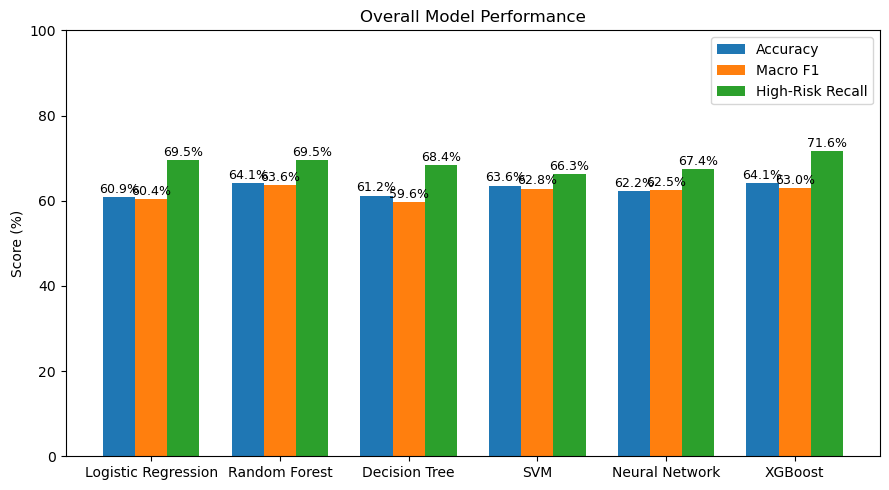

In [18]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Macro F1", "High-Risk Recall"]
models = final_results_df["Model"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 5))

for i, metric in enumerate(metrics):
    values = final_results_df[metric] * 100
    bars = plt.bar(x + i * width, values, width, label=metric)

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center",
            fontsize=9
        )

plt.xticks(x + width, models)
plt.ylabel("Score (%)")
plt.title("Overall Model Performance")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

#### 2. High-risk detection
Visualizes how many high-risk cases were caught vs missed.

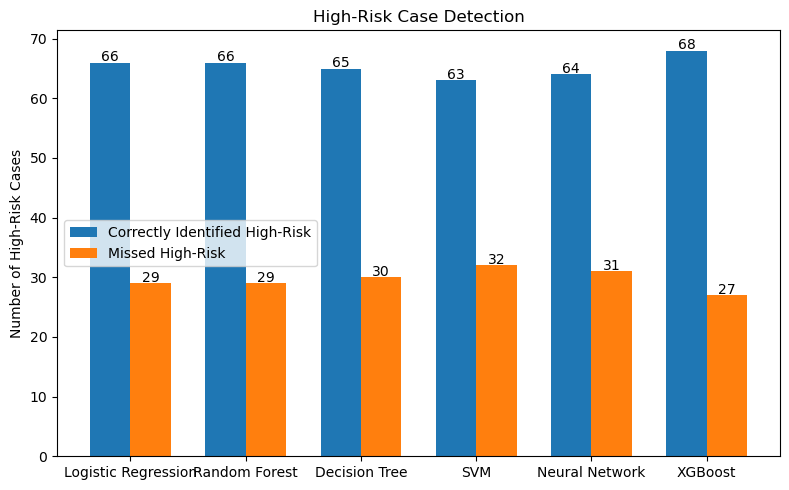

In [19]:
models = high_risk_fnr_df["Model"]
true_positives = high_risk_fnr_df["High-Risk True Positives"]
false_negatives = high_risk_fnr_df["High-Risk False Negatives"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    true_positives,
    width,
    label="Correctly Identified High-Risk"
)

bars2 = plt.bar(
    x + width/2,
    false_negatives,
    width,
    label="Missed High-Risk"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            str(int(bar.get_height())),
            ha="center"
        )

plt.xticks(x, models)
plt.ylabel("Number of High-Risk Cases")
plt.title("High-Risk Case Detection")
plt.legend()
plt.tight_layout()
plt.show()

#### 3. High-risk recall vs false-negative rate


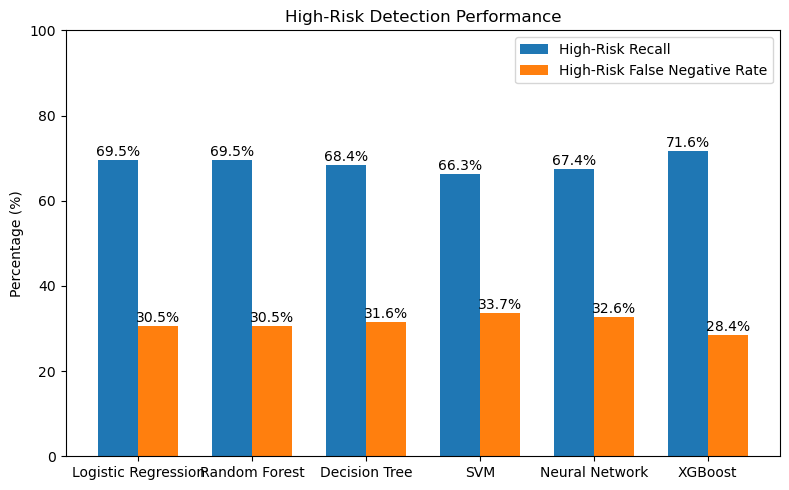

In [20]:
models = final_results_df["Model"]

high_risk_recall = final_results_df["High-Risk Recall"] * 100
high_risk_fnr = final_results_df["High-Risk False Negative Rate"] * 100

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    high_risk_recall,
    width,
    label="High-Risk Recall"
)

bars2 = plt.bar(
    x + width/2,
    high_risk_fnr,
    width,
    label="High-Risk False Negative Rate"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center"
        )

plt.xticks(x, models)
plt.ylabel("Percentage (%)")
plt.title("High-Risk Detection Performance")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Calibration of Final Candidate Models

Calibration is applied after model selection to assess and improve probability quality.  
For a fair final comparison, the calibrated models are evaluated on the same untouched test set.

The section below calibrates **Random Forest, SVM, and XGBoost**, which can then be compared on:
- Accuracy
- Macro F1
- High-Risk Recall
- High-Risk False Negatives / FNR
- Multiclass Log Loss

Lower log loss indicates better probability quality.


In [21]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

# RF calibration
calibrated_rf = CalibratedClassifierCV(
    estimator=best_rf_model,
    method="sigmoid",
    cv=5
)
calibrated_rf.fit(X_train, y_train)

# SVM calibration
calibrated_svm = CalibratedClassifierCV(
    estimator=best_svm_model,
    method="sigmoid",
    cv=5
)
calibrated_svm.fit(X_train, y_train)

# XGBoost calibration uses encoded labels
calibrated_xgb = CalibratedClassifierCV(
    estimator=best_xgb_model,
    method="sigmoid",
    cv=5
)
calibrated_xgb.fit(X_train, y_train_xgb)

# Predictions
y_pred_rf_cal = calibrated_rf.predict(X_test)
y_pred_svm_cal = calibrated_svm.predict(X_test)

y_pred_xgb_cal_encoded = calibrated_xgb.predict(X_test).astype(int)
y_pred_xgb_cal = xgb_label_encoder.inverse_transform(y_pred_xgb_cal_encoded)

print("Calibration complete for RF, SVM, and XGBoost.")


Calibration complete for RF, SVM, and XGBoost.


In [22]:
# Build a directly comparable calibrated-candidate table
calibrated_candidates = {
    "Random Forest (Calibrated)": (
        y_pred_rf_cal,
        calibrated_rf.predict_proba(X_test),
        list(calibrated_rf.classes_)
    ),
    "SVM (Calibrated)": (
        y_pred_svm_cal,
        calibrated_svm.predict_proba(X_test),
        list(calibrated_svm.classes_)
    ),
}

# XGBoost probabilities have encoded class order; convert true labels for log loss.
xgb_proba_cal = calibrated_xgb.predict_proba(X_test)

calibration_rows = []

for model_name, (pred, proba, classes) in calibrated_candidates.items():
    actual_high = (y_test == "high risk")
    predicted_high = (pred == "high risk")
    tp = int((actual_high & predicted_high).sum())
    fn = int((actual_high & ~predicted_high).sum())

    calibration_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "High-Risk Recall": recall_score(
            y_test, pred, labels=["high risk"], average=None, zero_division=0
        )[0],
        "High-Risk False Negatives": fn,
        "High-Risk FNR": fn / (tp + fn),
        "Log Loss": log_loss(y_test, proba, labels=classes)
    })

# XGBoost row
actual_high = (y_test == "high risk")
predicted_high = (y_pred_xgb_cal == "high risk")
tp = int((actual_high & predicted_high).sum())
fn = int((actual_high & ~predicted_high).sum())

calibration_rows.append({
    "Model": "XGBoost (Calibrated)",
    "Accuracy": accuracy_score(y_test, y_pred_xgb_cal),
    "Macro F1": f1_score(y_test, y_pred_xgb_cal, average="macro", zero_division=0),
    "High-Risk Recall": recall_score(
        y_test, y_pred_xgb_cal, labels=["high risk"], average=None, zero_division=0
    )[0],
    "High-Risk False Negatives": fn,
    "High-Risk FNR": fn / (tp + fn),
    "Log Loss": log_loss(
        xgb_label_encoder.transform(y_test),
        xgb_proba_cal,
        labels=list(calibrated_xgb.classes_)
    )
})

calibrated_comparison_df = pd.DataFrame(calibration_rows)
calibrated_comparison_df


,Model,Accuracy,Macro F1,High-Risk Recall,High-Risk False Negatives,High-Risk FNR,Log Loss
0,Random Forest (Calibrated),0.654255,0.645138,0.663158,32,0.336842,0.785885
1,SVM (Calibrated),0.609043,0.592997,0.684211,30,0.315789,0.844114
2,XGBoost (Calibrated),0.646277,0.631303,0.684211,30,0.315789,0.793479


## 5. Final Six-Model Comparison for Presentation

This table uses the same test set for all six tuned models. It highlights both overall classification performance and the project's priority metric: detection of high-risk cases.


In [24]:
# PPT-ready final table
ppt_table = final_results_df[
    [
        "Model",
        "Accuracy",
        "Macro F1",
        "High-Risk Recall",
        "High-Risk False Negatives",
        "High-Risk False Negative Rate"
    ]
].copy()

for col in ["Accuracy", "Macro F1", "High-Risk Recall", "High-Risk False Negative Rate"]:
    ppt_table[col] = (ppt_table[col] * 100).round(1)

ppt_table = ppt_table.rename(columns={
    "Accuracy": "Accuracy (%)",
    "Macro F1": "Macro F1 (%)",
    "High-Risk Recall": "High-Risk Recall (%)",
    "High-Risk False Negative Rate": "High-Risk FNR (%)"
})

ppt_table.sort_values("Macro F1 (%)", ascending=False)

,Model,Accuracy (%),Macro F1 (%),High-Risk Recall (%),High-Risk False Negatives,High-Risk FNR (%)
1,Random Forest,64.1,63.6,69.5,29,30.5
5,XGBoost,64.1,63.0,71.6,27,28.4
3,SVM,63.6,62.8,66.3,32,33.7
4,Neural Network,62.2,62.5,67.4,31,32.6
0,Logistic Regression,60.9,60.4,69.5,29,30.5
2,Decision Tree,61.2,59.6,68.4,30,31.6


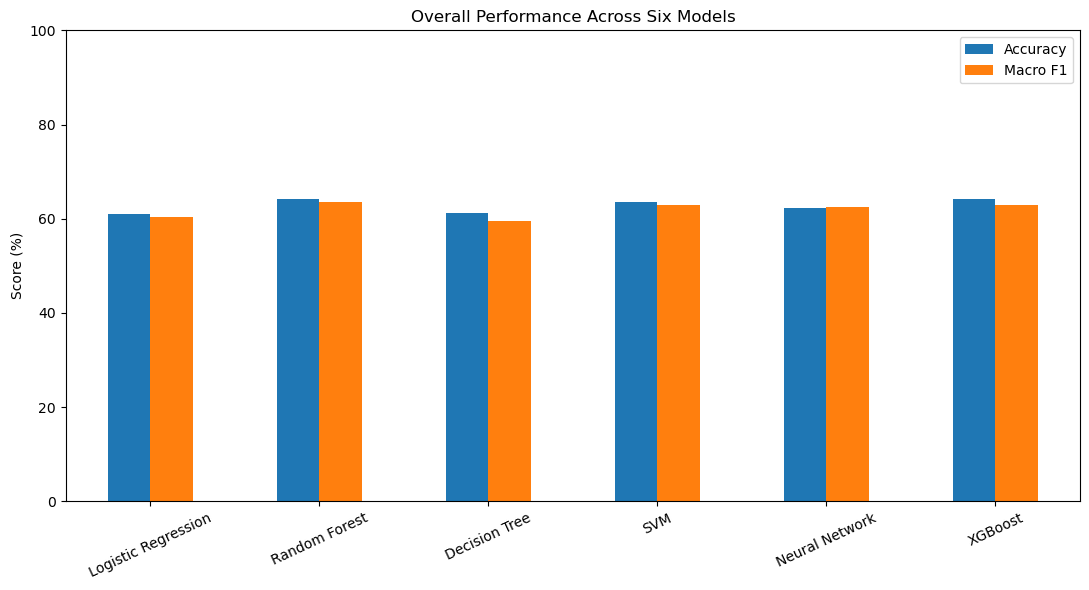

In [25]:
# PPT Visual 1: Overall performance
plot_df = final_results_df.set_index("Model")[["Accuracy", "Macro F1"]] * 100

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("Overall Performance Across Six Models")
ax.set_ylabel("Score (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


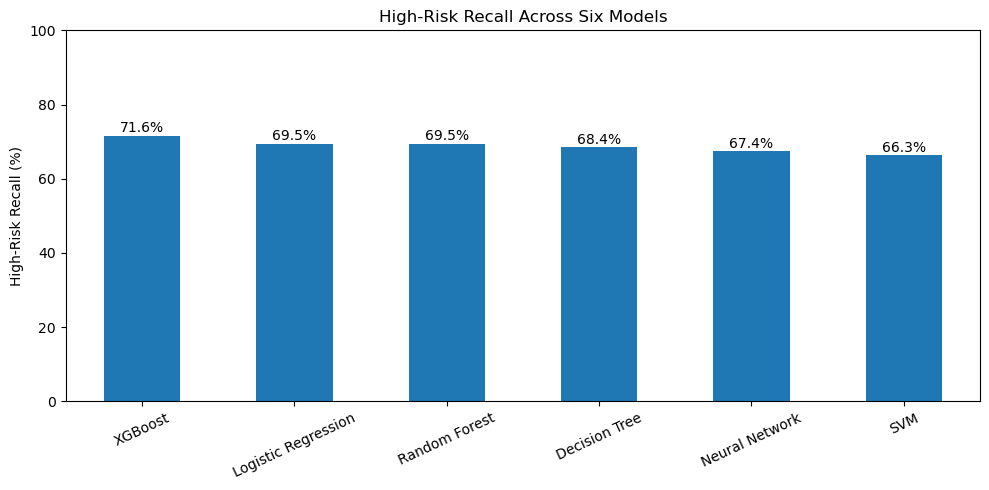

In [26]:
# PPT Visual 2: High-risk recall
high_risk_plot = (
    final_results_df
    .sort_values("High-Risk Recall", ascending=False)
    .set_index("Model")["High-Risk Recall"] * 100
)

ax = high_risk_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("High-Risk Recall Across Six Models")
ax.set_ylabel("High-Risk Recall (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)

for i, value in enumerate(high_risk_plot.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()


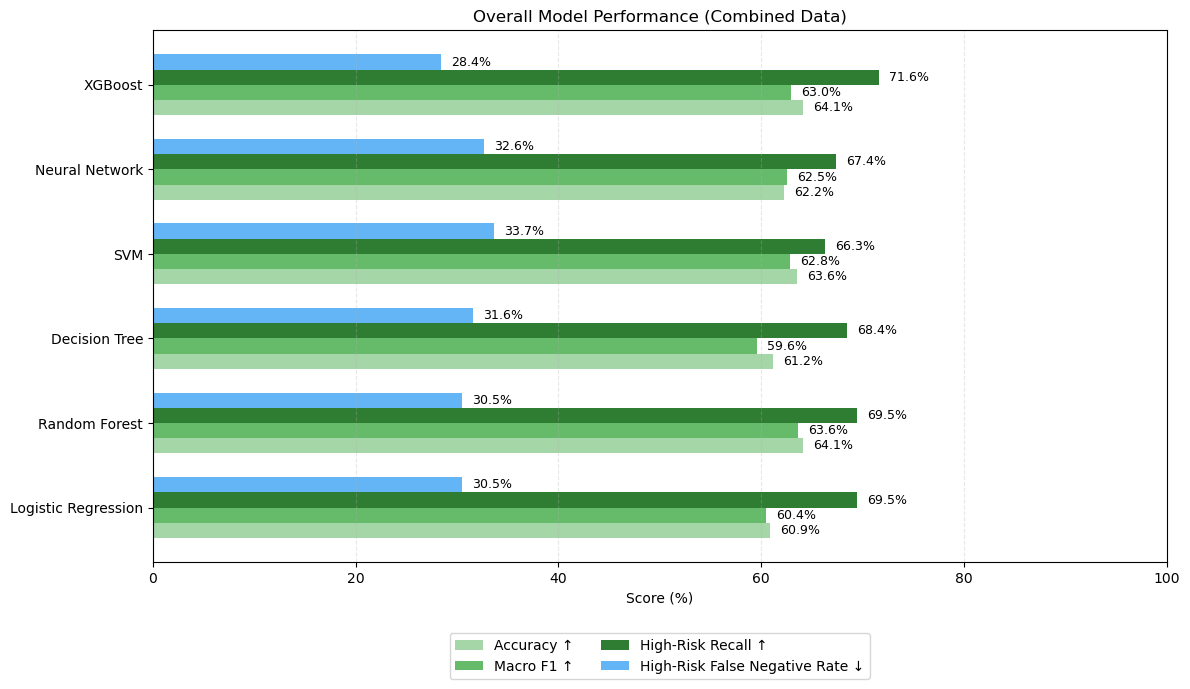

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Pull all results directly from final_results_df
models = final_results_df["Model"]

accuracy = final_results_df["Accuracy"] * 100
macro_f1 = final_results_df["Macro F1"] * 100
high_risk_recall = final_results_df["High-Risk Recall"] * 100
high_risk_fnr = final_results_df["High-Risk False Negative Rate"] * 100

y = np.arange(len(models))
height = 0.18

plt.figure(figsize=(12, 7))

# Higher values are desirable
bars1 = plt.barh(
    y - 1.5 * height, accuracy, height,
    label="Accuracy ↑", color="#A5D6A7"
)

bars2 = plt.barh(
    y - 0.5 * height, macro_f1, height,
    label="Macro F1 ↑", color="#66BB6A"
)

bars3 = plt.barh(
    y + 0.5 * height, high_risk_recall, height,
    label="High-Risk Recall ↑", color="#2E7D32"
)

# Lower values are desirable
bars4 = plt.barh(
    y + 1.5 * height, high_risk_fnr, height,
    label="High-Risk False Negative Rate ↓", color="#64B5F6"
)

# Labels are also generated directly from the actual values
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        value = bar.get_width()
        plt.text(
            value + 1,
            bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%",
            va="center",
            fontsize=9
        )

plt.yticks(y, models)
plt.xlabel("Score (%)")
plt.title("Overall Model Performance (Combined Data)")

plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.legend(
    bbox_to_anchor=(0.5, -0.12),
    loc="upper center",
    ncol=2
)

plt.tight_layout()
plt.show()

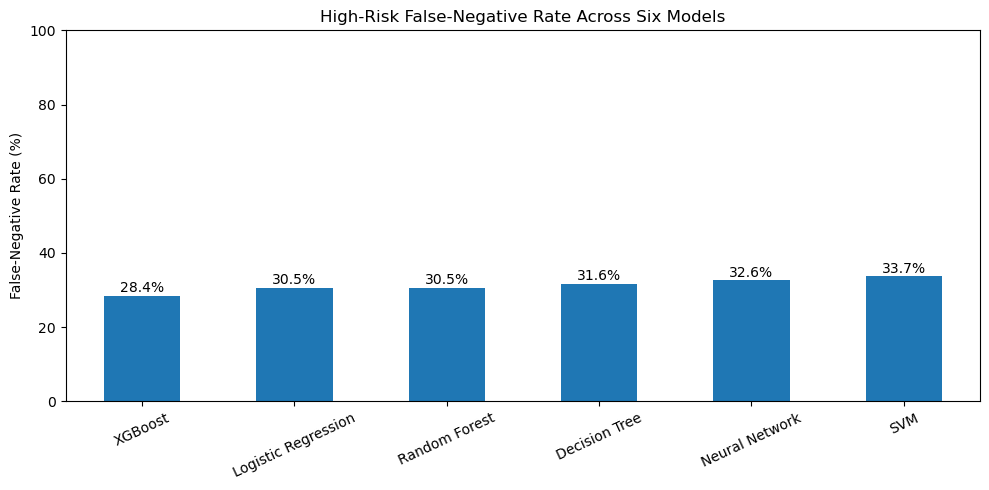

In [27]:
# PPT Visual 3: High-risk false-negative rate
fnr_plot = (
    final_results_df
    .sort_values("High-Risk False Negative Rate")
    .set_index("Model")["High-Risk False Negative Rate"] * 100
)

ax = fnr_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("High-Risk False-Negative Rate Across Six Models")
ax.set_ylabel("False-Negative Rate (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)

for i, value in enumerate(fnr_plot.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()


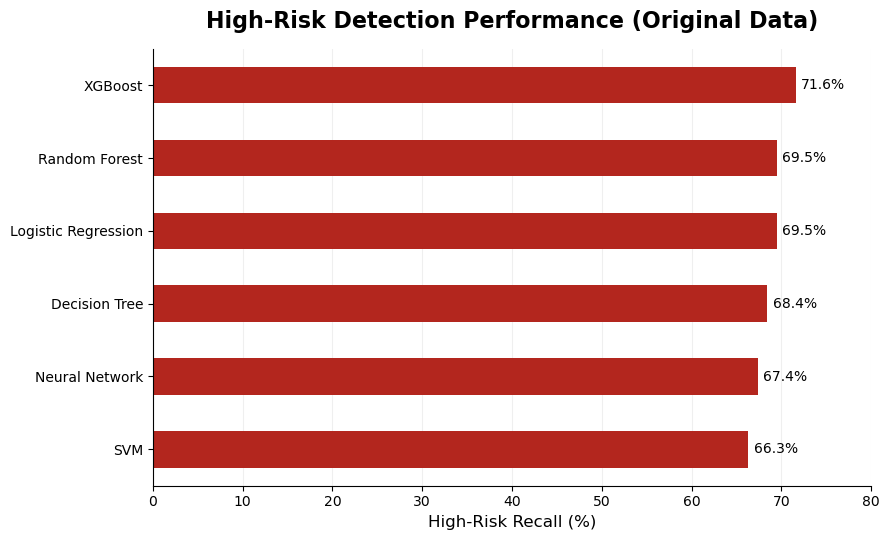

In [30]:
# PPT Visual 2: High-Risk Recall

high_risk_plot = (
    final_results_df
    .sort_values("High-Risk Recall", ascending=True)
    .set_index("Model")["High-Risk Recall"]
    * 100
)

ax = high_risk_plot.plot(
    kind="barh",
    figsize=(9, 5.5),
    color="#B3261E"
)

ax.set_title(
    "High-Risk Detection Performance (Original Data)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("High-Risk Recall (%)", fontsize=12)
ax.set_ylabel("")
ax.set_xlim(0, 80)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

# Values beside bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4,
        fontsize=10
    )

plt.tight_layout()
plt.show()